# Milestone 5 — Fine-Tuning Pre-trained Audio Transformers
## Audio Spectrogram Transformer (AST) from HuggingFace


In [24]:
!pip install transformers accelerate wandb -q

In [25]:
import os, random, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# HuggingFace
from transformers import AutoFeatureExtractor, ASTForAudioClassification

from sklearn.metrics import f1_score, classification_report, confusion_matrix
import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
# CONFIG

SR           = 16000       # AST requires 16kHz
DURATION     = 5           # seconds
SAMPLES      = SR * DURATION  # 80000

# Training
BATCH_SIZE   = 16          # smaller batch — AST is large (86M params)
EPOCHS_P1    = 3           # Phase 1: head only
EPOCHS_P2    = 2         # Phase 2: full fine-tune
LR_P1        = 1e-3        # higher LR for new head only
LR_P2        = 5e-5        # low LR to gently adjust pretrained weights
WD           = 1e-4
NUM_CLASSES  = 10
NUM_WORKERS  = 2

# Data — same as M4
N_AUG        = 8           # augmented mashups per training song
N_VAL        = 100         # val samples per genre (1000 total)
NOISE_MIN    = 0.05
NOISE_MAX    = 0.35
N_TTA        = 8           # test-time augmentation

# Pretrained model
MODEL_NAME   = 'MIT/ast-finetuned-audioset-10-10-0.4593'

# Reference scores from previous milestones
M3_LB        = 0.80789
M4_LB        = 0.83917

GENRES = sorted(['blues','classical','country','disco','hiphop',
                 'jazz','metal','pop','reggae','rock'])
G2I = {g:i for i,g in enumerate(GENRES)}
I2G = {i:g for g,i in G2I.items()}

BASE = None
for p in ['/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup',
          '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup']:
    if os.path.exists(p): BASE = p; break
assert BASE

GENRES_PATH  = f'{BASE}/genres_stems'
NOISE_PATH   = f'{BASE}/ESC-50-master/audio'
MASHUPS_PATH = f'{BASE}/mashups'
TEST_CSV     = f'{BASE}/test.csv'

print(f'Dataset: {BASE}')
print(f'Model:   {MODEL_NAME}')
print(f'SR:      {SR} Hz (AST requires 16kHz, not 22050)')
print(f'Batch:   {BATCH_SIZE} (smaller because AST is 86M params)')
print(f'Phases:  P1={EPOCHS_P1}ep@LR={LR_P1} (head only) | P2={EPOCHS_P2}ep@LR={LR_P2} (full)')

Dataset: /kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup
Model:   MIT/ast-finetuned-audioset-10-10-0.4593
SR:      16000 Hz (AST requires 16kHz, not 22050)
Batch:   16 (smaller because AST is 86M params)
Phases:  P1=3ep@LR=0.001 (head only) | P2=2ep@LR=5e-05 (full)


In [ ]:
# LOAD HUGGINGFACE FEATURE EXTRACTOR


print(f'Loading feature extractor: {MODEL_NAME}')
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

print(f'Feature extractor settings:')
print(f'  sampling_rate:     {feature_extractor.sampling_rate}')
print(f'  num_mel_bins:      {feature_extractor.num_mel_bins}')
print(f'  max_length:        {feature_extractor.max_length}')
print(f'  mean:              {feature_extractor.mean:.4f}  (AudioSet normalization)')
print(f'  std:               {feature_extractor.std:.4f}')

# Test it
dummy_audio = np.zeros(SAMPLES, dtype=np.float32)
dummy_out   = feature_extractor(dummy_audio, sampling_rate=SR, return_tensors='pt')
print(f'\nFeature extractor output shape: {dummy_out["input_values"].shape}')
print(f'  = (batch, time_frames, mel_bins)')

Loading feature extractor: MIT/ast-finetuned-audioset-10-10-0.4593
Feature extractor settings:
  sampling_rate:     16000
  num_mel_bins:      128
  max_length:        1024
  mean:              -4.2677  (AudioSet normalization)
  std:               4.5690

Feature extractor output shape: torch.Size([1, 1024, 128])
  = (batch, time_frames, mel_bins)


In [ ]:
# CATALOG + SPLIT — same seed as M3/M4

catalog = {}
for g in GENRES:
    gdir = f'{GENRES_PATH}/{g}'
    songs = sorted([f'{gdir}/{s}' for s in os.listdir(gdir)
                    if os.path.isdir(f'{gdir}/{s}')])
    catalog[g] = songs
    print(f'  {g:12s}: {len(songs)} songs')

STEMS = [f for f in os.listdir(catalog[GENRES[0]][0]) if f.endswith('.wav')]
print(f'Stems: {STEMS}')
noise_files = [f'{NOISE_PATH}/{f}' for f in os.listdir(NOISE_PATH) if f.endswith('.wav')]
print(f'Noise files: {len(noise_files)}')

rng = random.Random(SEED)
tr_songs, vl_songs = {}, {}
for g, songs in catalog.items():
    s = songs.copy(); rng.shuffle(s)
    n = max(2, int(len(s)*0.15))
    vl_songs[g] = s[:n]; tr_songs[g] = s[n:]
print('Split:', {g: f'{len(tr_songs[g])}tr/{len(vl_songs[g])}vl' for g in GENRES})

  blues       : 100 songs
  classical   : 100 songs
  country     : 100 songs
  disco       : 100 songs
  hiphop      : 100 songs
  jazz        : 100 songs
  metal       : 100 songs
  pop         : 100 songs
  reggae      : 100 songs
  rock        : 100 songs
Stems: ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
Noise files: 2000
Split: {'blues': '85tr/15vl', 'classical': '85tr/15vl', 'country': '85tr/15vl', 'disco': '85tr/15vl', 'hiphop': '85tr/15vl', 'jazz': '85tr/15vl', 'metal': '85tr/15vl', 'pop': '85tr/15vl', 'reggae': '85tr/15vl', 'rock': '85tr/15vl'}


In [ ]:
# AUDIO HELPERS


def load_stem(path):
    try:
        y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION+2)
        if len(y) < SAMPLES: y = np.pad(y, (0, SAMPLES-len(y)))
        else:
            s = random.randint(0, len(y)-SAMPLES); y = y[s:s+SAMPLES]
        return y.astype(np.float32)
    except: return np.zeros(SAMPLES, np.float32)

def load_noise():
    try:
        y, _ = librosa.load(random.choice(noise_files), sr=SR, mono=True)
        if len(y) < SAMPLES: y = np.tile(y, (SAMPLES//len(y))+1)
        s = random.randint(0, len(y)-SAMPLES)
        return y[s:s+SAMPLES].astype(np.float32)
    except: return np.zeros(SAMPLES, np.float32)

def make_mashup(genre, song_pool):
    """Same domain-shift fix: 4 different songs + ESC-50 noise."""
    songs = random.choices(song_pool[genre], k=4)
    stems = STEMS.copy(); random.shuffle(stems)
    mixed = np.zeros(SAMPLES, np.float32)
    for song, stem in zip(songs, stems[:4]):
        y = load_stem(f'{song}/{stem}')
        mx = np.max(np.abs(y))
        if mx > 0: y /= (mx + 1e-6)
        mixed += random.uniform(0.4, 1.0) * y
    mx = np.max(np.abs(mixed))
    if mx > 0: mixed /= (mx + 1e-6)
    noise = load_noise()
    mixed += random.uniform(NOISE_MIN, NOISE_MAX) * noise
    mx = np.max(np.abs(mixed))
    if mx > 0: mixed /= (mx + 1e-6)
    return mixed

def extract_features(audio):
    """
    Convert raw audio → AST input features using HuggingFace extractor.
    Returns tensor of shape (1, time, mel_bins) ready for AST.
    """
    out = feature_extractor(
        audio,
        sampling_rate=SR,
        return_tensors='pt',
        padding=True
    )
    return out['input_values'].squeeze(0)  # (time_frames, mel_bins)

print('Audio helpers ready.')
print(f'SR = {SR} Hz (downsampled from 22050 for AST)')

# Test
test_audio = make_mashup('rock', tr_songs)
test_feat  = extract_features(test_audio)
print(f'Mashup shape:   {test_audio.shape}  (raw audio)')
print(f'Feature shape:  {test_feat.shape}   (AST input)')

Audio helpers ready.
SR = 16000 Hz (downsampled from 22050 for AST)
Mashup shape:   (80000,)  (raw audio)
Feature shape:  torch.Size([1024, 128])   (AST input)


In [ ]:
# PRE-COMPUTE FEATURES  (~20-25 min)

n_tr = sum(len(v) for v in tr_songs.values()) * N_AUG
n_vl = len(GENRES) * N_VAL
print(f'Pre-computing {n_tr} train + {n_vl} val features...')
print('(Runs once — then training is fast)')

X_tr, y_tr = [], []
X_vl, y_vl = [], []
t0 = time.time()

for g in GENRES:
    lbl = G2I[g]
    for _ in tqdm(range(len(tr_songs[g]) * N_AUG), desc=f'TR {g}', leave=False):
        audio = make_mashup(g, tr_songs)
        X_tr.append(extract_features(audio).numpy())
        y_tr.append(lbl)
    for _ in tqdm(range(N_VAL), desc=f'VL {g}', leave=False):
        audio = make_mashup(g, vl_songs)
        X_vl.append(extract_features(audio).numpy())
        y_vl.append(lbl)

X_tr = np.array(X_tr, np.float32)
y_tr = np.array(y_tr, np.int64)
X_vl = np.array(X_vl, np.float32)
y_vl = np.array(y_vl, np.int64)

print(f'\nDone in {(time.time()-t0)/60:.1f} min')
print(f'X_tr: {X_tr.shape}  ({X_tr.nbytes/1e6:.0f} MB)')
print(f'X_vl: {X_vl.shape}  ({X_vl.nbytes/1e6:.0f} MB)')
print(f'Train: {np.bincount(y_tr)} | Val: {np.bincount(y_vl)}')

Pre-computing 6800 train + 1000 val features...
(Runs once — then training is fast)



Done in 7.4 min
X_tr: (6800, 1024, 128)  (3565 MB)
X_vl: (1000, 1024, 128)  (524 MB)
Train: [680 680 680 680 680 680 680 680 680 680] | Val: [100 100 100 100 100 100 100 100 100 100]


In [ ]:
# DATASET

class AudioDataset(Dataset):
    """
    Simple dataset reading pre-computed AST features from RAM.
    No augmentation here — augmentation was applied during pre-computation
    (random crops, random stems, random noise level).
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X)   # (N, time, mel_bins)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

tr_ds = AudioDataset(X_tr, y_tr)
vl_ds = AudioDataset(X_vl, y_vl)
tr_dl = DataLoader(tr_ds, BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
vl_dl = DataLoader(vl_ds, BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(tr_ds)} samples | {len(tr_dl)} batches')
print(f'Val:   {len(vl_ds)} samples | {len(vl_dl)} batches')
xb, yb = next(iter(tr_dl))
print(f'Batch input shape: {xb.shape}  ← (batch, time_frames, mel_bins)')

Train: 6800 samples | 425 batches
Val:   1000 samples | 63 batches
Batch input shape: torch.Size([16, 1024, 128])  ← (batch, time_frames, mel_bins)


In [ ]:
# LOAD AST MODEL

print(f'Loading pretrained model: {MODEL_NAME}')
model = ASTForAudioClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,         # replace 527-class head with 10-class
    ignore_mismatched_sizes=True,   # allows head size to differ
    label2id=G2I,
    id2label=I2G,
)
model = model.to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_p     = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel loaded!')
print(f'  Total parameters:    {total_params:,}')
print(f'  Trainable (all):     {trainable_p:,}')
print(f'  Compare: M3 CNN had 2.4M, M4 CRNN had 2.75M')
print(f'  AST has {total_params/1e6:.0f}M — 30x larger!')

# Test forward pass
with torch.no_grad():
    dummy = xb[:2].to(DEVICE)
    out   = model(input_values=dummy)
    print(f'\nForward pass: input {dummy.shape} → logits {out.logits.shape}  ✅')

Loading pretrained model: MIT/ast-finetuned-audioset-10-10-0.4593


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                        
------------------------+----------+----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



Model loaded!
  Total parameters:    86,196,490
  Trainable (all):     86,196,490
  Compare: M3 CNN had 2.4M, M4 CRNN had 2.75M
  AST has 86M — 30x larger!

Forward pass: input torch.Size([2, 1024, 128]) → logits torch.Size([2, 10])  ✅


In [ ]:
# HELPER: freeze / unfreeze model layers

def freeze_encoder(model):
    """Freeze all layers except the classification head."""
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    frozen   = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Frozen: {frozen:,} | Trainable (head only): {trainable:,}')

def unfreeze_all(model):
    """Unfreeze all layers for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  All layers unfrozen. Trainable: {trainable:,}')

print('Freeze/unfreeze helpers ready.')

Freeze/unfreeze helpers ready.


In [ ]:
# W&B INIT

# wandb.login()  
# run = wandb.init(
#     project='genre-classification',  
#     name='milestone5-ast-finetune',
#     config=dict(
#         architecture   = 'AST (Audio Spectrogram Transformer)',
#         pretrained_on  = 'AudioSet (2M clips, 527 classes)',
#         model_name     = MODEL_NAME,
#         sr             = SR,
#         duration       = DURATION,
#         batch_size     = BATCH_SIZE,
#         epochs_phase1  = EPOCHS_P1,
#         epochs_phase2  = EPOCHS_P2,
#         lr_phase1      = LR_P1,
#         lr_phase2      = LR_P2,
#         weight_decay   = WD,
#         n_aug          = N_AUG,
#         n_val          = N_VAL,
#         n_tta          = N_TTA,
#         m3_lb          = M3_LB,
#         m4_lb          = M4_LB,
#     ),
#     tags=['milestone-5', 'ast', 'transfer-learning', 'huggingface']
# )
# print(f'W&B run: {run.url}')

In [ ]:
# TRAINING FUNCTIONS

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_ep(model, dl, optimizer):
    model.train()
    loss_sum, ps, ls = 0.0, [], []
    for x, y in dl:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        # AST forward: pass input_values keyword argument
        logits = model(input_values=x).logits
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item()
        ps.extend(logits.argmax(1).cpu().numpy())
        ls.extend(y.cpu().numpy())
    return loss_sum/len(dl), f1_score(ls, ps, average='macro')


@torch.no_grad()
def val_ep(model, dl):
    model.eval()
    loss_sum, ps, ls, probs_all = 0.0, [], [], []
    for x, y in dl:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(input_values=x).logits
        loss_sum += criterion(logits, y).item()
        probs = F.softmax(logits, 1)
        ps.extend(probs.argmax(1).cpu().numpy())
        ls.extend(y.cpu().numpy())
        probs_all.append(probs.cpu().numpy())
    return (loss_sum/len(dl),
            f1_score(ls, ps, average='macro'),
            ps, ls,
            np.vstack(probs_all))

print('Training functions ready.')

Training functions ready.


In [ ]:
# PHASE 1 — Train head only

print('═'*60)
print('PHASE 1: Head-only training')
print('  Encoder FROZEN — only classifier head trains')
print(f'  LR = {LR_P1} | Epochs = {EPOCHS_P1}')
print('═'*60)

freeze_encoder(model)
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=WD
)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=EPOCHS_P1, eta_min=1e-5
)

best_f1 = 0.0
best_ep  = 0
hist = {k: [] for k in ['tl','tf','vl','vf','phase']}

t_all = time.time()
for ep in range(EPOCHS_P1):
    t0 = time.time()
    tl, tf = train_ep(model, tr_dl, optimizer_p1)
    vl, vf, _, _, _ = val_ep(model, vl_dl)
    scheduler_p1.step()
    lr = scheduler_p1.get_last_lr()[0]

    for k,v in zip(['tl','tf','vl','vf','phase'],
                   [tl, tf, vl, vf, 1]):
        hist[k].append(v)

    # wandb.log({'epoch': ep+1, 'phase': 1,
    #            'train/loss': tl, 'train/f1': tf,
    #            'val/loss': vl, 'val/f1': vf, 'lr': lr})

    flag = ''
    if vf > best_f1:
        best_f1, best_ep = vf, ep+1
        torch.save({'ep':ep+1,'state':model.state_dict(),'f1':vf}, 'best_ast.pth')
        flag = ' ✨'

    print(f'P1 Ep {ep+1:02d}/{EPOCHS_P1} | '
          f'Tr {tl:.4f}/{tf:.4f} | '
          f'Vl {vl:.4f}/{vf:.4f} | '
          f'{time.time()-t0:.0f}s{flag}')

print(f'\nPhase 1 done. Best val F1: {best_f1:.4f}')

════════════════════════════════════════════════════════════
PHASE 1: Head-only training
  Encoder FROZEN — only classifier head trains
  LR = 0.001 | Epochs = 3
════════════════════════════════════════════════════════════
  Frozen: 86,187,264 | Trainable (head only): 9,226
P1 Ep 01/3 | Tr 1.0224/0.7968 | Vl 0.9788/0.8259 | 685s ✨
P1 Ep 02/3 | Tr 0.8287/0.8933 | Vl 0.9655/0.8350 | 684s ✨
P1 Ep 03/3 | Tr 0.7677/0.9265 | Vl 0.9185/0.8522 | 682s ✨

Phase 1 done. Best val F1: 0.8522


In [ ]:
# PHASE 2 — Full fine-tuning

print('═'*60)
print('PHASE 2: Full fine-tuning')
print('  ALL layers unfrozen')
print(f'  LR = {LR_P2} (10x smaller than P1) | Epochs = {EPOCHS_P2}')
print('═'*60)

unfreeze_all(model)
optimizer_p2 = optim.AdamW(
    model.parameters(),
    lr=LR_P2, weight_decay=WD
)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=EPOCHS_P2, eta_min=1e-7
)

ep_offset = EPOCHS_P1

for ep in range(EPOCHS_P2):
    t0 = time.time()
    tl, tf = train_ep(model, tr_dl, optimizer_p2)
    vl, vf, _, _, _ = val_ep(model, vl_dl)
    scheduler_p2.step()
    lr = scheduler_p2.get_last_lr()[0]

    for k,v in zip(['tl','tf','vl','vf','phase'],
                   [tl, tf, vl, vf, 2]):
        hist[k].append(v)

    # wandb.log({'epoch': ep_offset+ep+1, 'phase': 2,
    #            'train/loss': tl, 'train/f1': tf,
    #            'val/loss': vl, 'val/f1': vf, 'lr': lr})

    flag = ''
    if vf > best_f1:
        best_f1, best_ep = vf, ep_offset+ep+1
        torch.save({'ep':ep_offset+ep+1,'state':model.state_dict(),'f1':vf}, 'best_ast.pth')
        flag = ' ✨'

    print(f'P2 Ep {ep+1:02d}/{EPOCHS_P2} | '
          f'Tr {tl:.4f}/{tf:.4f} | '
          f'Vl {vl:.4f}/{vf:.4f} | '
          f'{time.time()-t0:.0f}s{flag}')

total_time = (time.time()-t_all)/60
print(f'\n✅ Training complete in {total_time:.1f} min')
print(f'🏆 Best Val F1: {best_f1:.4f} (epoch {best_ep})')

════════════════════════════════════════════════════════════
PHASE 2: Full fine-tuning
  ALL layers unfrozen
  LR = 5e-05 (10x smaller than P1) | Epochs = 2
════════════════════════════════════════════════════════════
  All layers unfrozen. Trainable: 86,196,490
P2 Ep 01/2 | Tr 0.8718/0.8593 | Vl 0.9985/0.8061 | 2055s
P2 Ep 02/2 | Tr 0.5729/0.9850 | Vl 0.8517/0.8621 | 2054s ✨

✅ Training complete in 102.6 min
🏆 Best Val F1: 0.8621 (epoch 5)


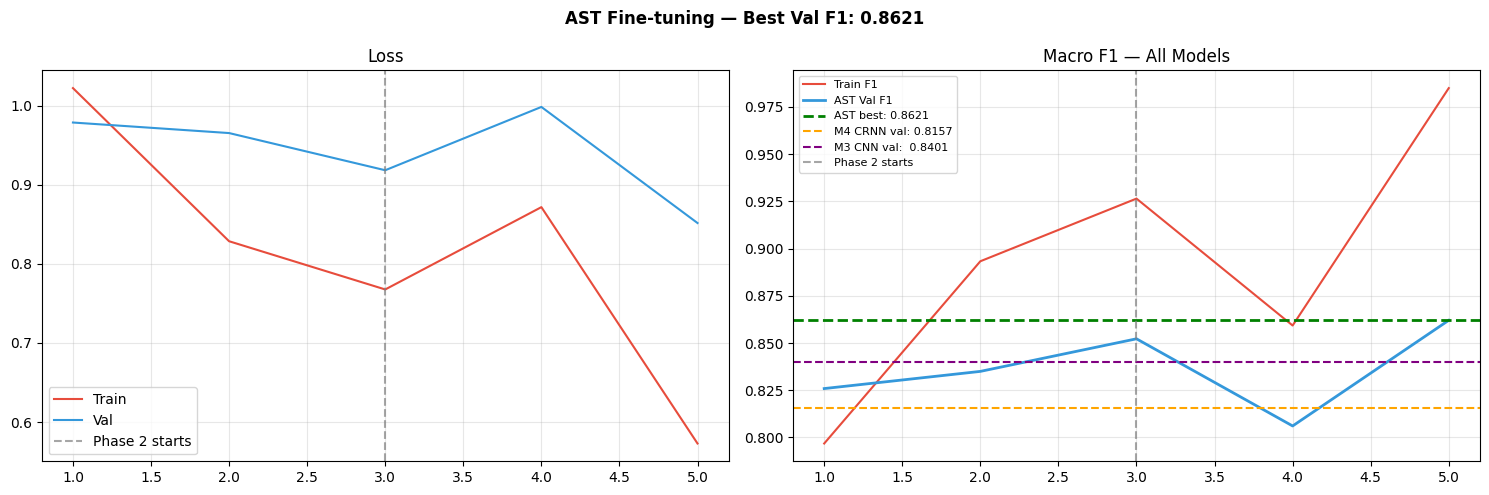

In [ ]:
# TRAINING CURVES + MODEL COMPARISON

total_eps = EPOCHS_P1 + EPOCHS_P2
ep_r = range(1, total_eps+1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(ep_r, hist['tl'], label='Train', color='#e74c3c')
axes[0].plot(ep_r, hist['vl'], label='Val',   color='#3498db')
axes[0].axvline(EPOCHS_P1, color='gray', ls='--', alpha=0.7, label='Phase 2 starts')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# F1 with all model comparisons
axes[1].plot(ep_r, hist['tf'], label='Train F1', color='#e74c3c')
axes[1].plot(ep_r, hist['vf'], label='AST Val F1', color='#3498db', lw=2)
axes[1].axhline(best_f1, color='green',  ls='--', lw=2, label=f'AST best: {best_f1:.4f}')
axes[1].axhline(0.8157,  color='orange', ls='--',       label=f'M4 CRNN val: 0.8157')
axes[1].axhline(0.8401,  color='purple', ls='--',       label=f'M3 CNN val:  0.8401')
axes[1].axvline(EPOCHS_P1, color='gray', ls='--', alpha=0.7, label='Phase 2 starts')
axes[1].set_title('Macro F1 — All Models')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle(f'AST Fine-tuning — Best Val F1: {best_f1:.4f}', fontweight='bold')
plt.tight_layout()
plt.savefig('ast_training.png', dpi=100)
plt.show()
# wandb.log({'training_curves': wandb.Image('ast_training.png')})

Loaded best AST: epoch 5, val F1=0.8621

MILESTONE COMPARISON: M3 → M4 → M5
  Model                       Val F1    LB Score    Params
  -------------------------------------------------------
  M3 CNN (from scratch)       0.8401     0.80789      2.4M
  M4 CRNN (CNN+BiGRU)         0.8157     0.83917     2.75M
  M5 AST (pretrained)         0.8621     submit!       86M
  M5 vs M4: +0.0464 val F1
  M5 vs M3: +0.0220 val F1

Per-Class F1:
              precision    recall  f1-score   support

       blues      0.927     0.890     0.908       100
   classical      0.977     0.840     0.903       100
     country      0.682     0.900     0.776       100
       disco      0.922     0.830     0.874       100
      hiphop      0.865     0.960     0.910       100
        jazz      0.845     0.980     0.907       100
       metal      0.943     1.000     0.971       100
         pop      0.886     0.780     0.830       100
      reggae      0.951     0.770     0.851       100
        rock      0.

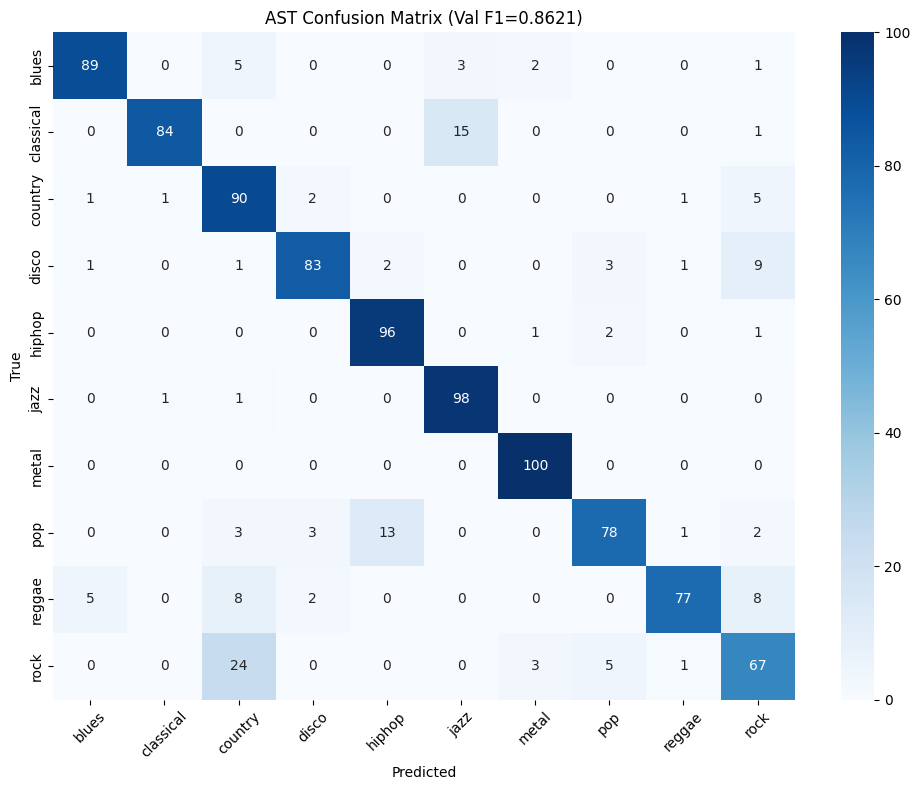

In [ ]:
# FULL MODEL COMPARISON TABLE

ckpt = torch.load('best_ast.pth', map_location=DEVICE)
model.load_state_dict(ckpt['state'])
print(f'Loaded best AST: epoch {ckpt["ep"]}, val F1={ckpt["f1"]:.4f}')

_, vf, vp, vl_true, _ = val_ep(model, vl_dl)

print('\n' + '='*60)
print('MILESTONE COMPARISON: M3 → M4 → M5')
print('='*60)
print(f'  {"Model":<25} {"Val F1":>8}  {"LB Score":>10}  {"Params":>8}')
print(f'  {"-"*55}')
print(f'  {"M3 CNN (from scratch)":<25} {"0.8401":>8}  {M3_LB:>10.5f}  {"2.4M":>8}')
print(f'  {"M4 CRNN (CNN+BiGRU)":<25} {"0.8157":>8}  {M4_LB:>10.5f}  {"2.75M":>8}')
print(f'  {"M5 AST (pretrained)":<25} {vf:>8.4f}  {"submit!":>10}  {"86M":>8}')
print('='*60)
print(f'  M5 vs M4: {vf-0.8157:+.4f} val F1')
print(f'  M5 vs M3: {vf-0.8401:+.4f} val F1')

print('\nPer-Class F1:')
print(classification_report(vl_true, vp, target_names=GENRES, digits=3))

cm = confusion_matrix(vl_true, vp)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.title(f'AST Confusion Matrix (Val F1={vf:.4f})')
plt.xticks(rotation=45); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('ast_cm.png', dpi=100); plt.show()
# wandb.log({'confusion_matrix': wandb.Image('ast_cm.png'), 'best_val_f1': vf})

In [ ]:
# INFERENCE WITH TTA

test_df = pd.read_csv(TEST_CSV)
lookup  = {}
for f in os.listdir(MASHUPS_PATH):
    if f.endswith('.wav'):
        num = int(f.replace('song','').replace('.wav',''))
        lookup[num] = f'{MASHUPS_PATH}/{f}'
print(f'Test: {len(test_df)} | Matched: {sum(1 for i in test_df["id"] if int(i) in lookup)}')

model.eval()
all_ids, all_preds = [], []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f'TTA×{N_TTA}'):
    sid = int(row['id'])
    fp  = lookup.get(sid)
    if not fp: all_ids.append(row['id']); all_preds.append('pop'); continue
    try:
        # Load at AST's required SR=16000
        audio, _ = librosa.load(fp, sr=SR, mono=True)
    except:
        all_ids.append(row['id']); all_preds.append('pop'); continue

    probs = np.zeros(NUM_CLASSES)
    for _ in range(N_TTA):
        # Random crop
        if len(audio) <= SAMPLES:
            seg = np.pad(audio, (0, SAMPLES-len(audio)))
        else:
            s   = random.randint(0, len(audio)-SAMPLES)
            seg = audio[s:s+SAMPLES]

        # Extract features using HF extractor
        feat = extract_features(seg.astype(np.float32)).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = model(input_values=feat).logits
            probs += F.softmax(logits, 1).cpu().numpy()[0]

    all_ids.append(row['id'])
    all_preds.append(I2G[np.argmax(probs)])

print(f'Done! {len(all_preds)} predictions')

Test: 3020 | Matched: 3020


TTA×8: 100%|██████████| 3020/3020 [37:05<00:00,  1.36it/s]

Done! 3020 predictions


In [ ]:
# SUBMISSION

sub = pd.DataFrame({'id': all_ids, 'genre': all_preds})
assert all(g in set(GENRES) for g in sub['genre'])
assert len(sub) == len(test_df)
sub.to_csv('submission.csv', index=False)

print('Prediction distribution:')
print(sub['genre'].value_counts())
print('\n✅ Saved: submission.csv')

# wandb.summary.update({
#     'ast_best_val_f1'  : best_f1,
#     'ast_best_epoch'   : best_ep,
#     'm3_lb'            : M3_LB,
#     'm4_lb'            : M4_LB,
#     'model_params'     : total_params,
# })
# wandb.finish()

print(f'\n{"="*60}')
print('FINAL COMPARISON: ALL MILESTONES')
print('='*60)
print(f'  M2  Logistic Reg:          LB = 0.30220')
print(f'  M3  CNN (scratch):   Val={0.8401:.4f}  LB = {M3_LB:.5f}')
print(f'  M4  CRNN (BiGRU):    Val={0.8157:.4f}  LB = {M4_LB:.5f}')
print(f'  M5  AST (pretrained):Val={best_f1:.4f}  LB = submit!')
print('='*60)

Prediction distribution:
genre
blues        377
rock         355
metal        341
hiphop       306
jazz         305
country      304
reggae       286
pop          281
disco        252
classical    213
Name: count, dtype: int64

✅ Saved: submission.csv

FINAL COMPARISON: ALL MILESTONES
  M2  Logistic Reg:          LB = 0.30220
  M3  CNN (scratch):   Val=0.8401  LB = 0.80789
  M4  CRNN (BiGRU):    Val=0.8157  LB = 0.83917
  M5  AST (pretrained):Val=0.8621  LB = submit!
